<a href="https://colab.research.google.com/github/its-afifa544/thesis-segmentation/blob/main/camvid_segformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CamVid semantic segmentation with SegFormer-B0
Baseline for the thesis pipeline. Runs top to bottom on a free Colab GPU.
Before running: Runtime > Change runtime type > T4 GPU.

In [1]:
!pip install -q transformers
!git clone -q --depth 1 https://github.com/alexgkendall/SegNet-Tutorial.git

In [2]:
import os, time, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode
from transformers import SegformerForSemanticSegmentation

# ---- Config -----------------------------------------------------------
ROOT = "SegNet-Tutorial/CamVid"
CLASSES = ["Sky", "Building", "Pole", "Road", "Pavement", "Tree",
           "Sign/Symbol", "Fence", "Car", "Pedestrian", "Bicyclist"]
NUM_CLASSES = 11      # label ids 0..10
IGNORE = 11           # "unlabelled" pixels, excluded from loss and metrics
CROP_H, CROP_W = 352, 480
BATCH = 8
EPOCHS = 40
LR = 6e-5             # encoder learning rate
HEAD_LR_MULT = 10     # new decoder head learns faster
SAVE_PATH = "segformer_b0_camvid_best.pt"
SEED = 0

device = "cuda" if torch.cuda.is_available() else "cpu"
use_amp = device == "cuda"
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print("device:", device)

device: cuda


## Data

In [3]:
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]


class CamVid(Dataset):
    def __init__(self, split, train=False):
        self.img_dir = f"{ROOT}/{split}"
        self.lab_dir = f"{ROOT}/{split}annot"
        self.names = sorted(os.listdir(self.img_dir))
        self.train = train

    def __len__(self):
        return len(self.names)

    def __getitem__(self, i):
        name = self.names[i]
        img = Image.open(f"{self.img_dir}/{name}").convert("RGB")
        lab = Image.open(f"{self.lab_dir}/{name}")

        if self.train:
            if random.random() < 0.5:                      # horizontal flip
                img, lab = TF.hflip(img), TF.hflip(lab)
            s = random.uniform(0.75, 1.5)                  # random scale
            size = [int(img.height * s), int(img.width * s)]
            img = TF.resize(img, size, interpolation=InterpolationMode.BILINEAR)
            lab = TF.resize(lab, size, interpolation=InterpolationMode.NEAREST)

        img = TF.normalize(TF.to_tensor(img), MEAN, STD)
        lab = torch.from_numpy(np.array(lab)).long()

        if self.train:
            h, w = lab.shape
            ph, pw = max(CROP_H - h, 0), max(CROP_W - w, 0)
            if ph or pw:                                   # pad small images
                img = F.pad(img, (0, pw, 0, ph), value=0.0)
                lab = F.pad(lab, (0, pw, 0, ph), value=IGNORE)
            h, w = lab.shape
            top = random.randint(0, h - CROP_H)
            left = random.randint(0, w - CROP_W)
            img = img[:, top:top + CROP_H, left:left + CROP_W]
            lab = lab[top:top + CROP_H, left:left + CROP_W]
        return img, lab


train_ds = CamVid("train", train=True)
val_ds = CamVid("val")
test_ds = CamVid("test")
print(len(train_ds), len(val_ds), len(test_ds))   # expect 367 101 233

train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                      num_workers=2, drop_last=True, pin_memory=True)
val_dl = DataLoader(val_ds, batch_size=BATCH, num_workers=2)
test_dl = DataLoader(test_ds, batch_size=BATCH, num_workers=2)

367 101 233


## Model
SegFormer-B0 with ImageNet-pretrained encoder (`nvidia/mit-b0`) and a fresh 11-class decoder head.

In [4]:
model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b0",
    num_labels=NUM_CLASSES,
    id2label={i: c for i, c in enumerate(CLASSES)},
    label2id={c: i for i, c in enumerate(CLASSES)},
    ignore_mismatched_sizes=True,
).to(device)

head_params = [p for n, p in model.named_parameters() if n.startswith("decode_head")]
enc_params = [p for n, p in model.named_parameters() if not n.startswith("decode_head")]
optimizer = torch.optim.AdamW(
    [{"params": enc_params, "lr": LR},
     {"params": head_params, "lr": LR * HEAD_LR_MULT}],
    weight_decay=0.01)

total_steps = EPOCHS * len(train_dl)
scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer, lambda step: (1 - step / total_steps) ** 0.9)   # poly decay
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
loss_fn = nn.CrossEntropyLoss(ignore_index=IGNORE)


def forward_logits(x, size):
    """SegFormer outputs 1/4 resolution logits; upsample to label size."""
    logits = model(pixel_values=x).logits
    return F.interpolate(logits.float(), size=size, mode="bilinear", align_corners=False)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/70.0k [00:00<?, ?B/s]

[transformers] You passed `num_labels=11` which is incompatible to the `id2label` map of length `1000`.


pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 14.4MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
classifier.weight                                       | UNEXPECTED | 
classifier.bias                                         | UNEXPECTED | 
decode_head.linear_fuse.weight                          | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.running_mean                     | MISSING    | 
decode_head.batch_norm.num_batches_tracked              | MISSING    | 
decode_head.classifier.bias                             | MISSING    | 
decode_head.batch_norm.weight                           | MISSING    | 
decode_head.batch_norm.bias                             | MISSING    | 
decode_head.classifier.weight                           

## Evaluation (mIoU)

In [5]:
@torch.no_grad()
def evaluate(loader):
    model.eval()
    conf = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.long, device=device)
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        with torch.autocast("cuda", dtype=torch.float16, enabled=use_amp):
            logits = forward_logits(x, y.shape[-2:])
        pred = logits.argmax(1)
        m = y < NUM_CLASSES                                  # drop void pixels
        idx = y[m] * NUM_CLASSES + pred[m]
        conf += torch.bincount(idx, minlength=NUM_CLASSES ** 2).view(NUM_CLASSES, NUM_CLASSES)
    conf = conf.double()
    tp = conf.diag()
    denom = conf.sum(0) + conf.sum(1) - tp
    iou = torch.where(denom > 0, tp / denom.clamp(min=1), torch.full_like(tp, float("nan")))
    pix_acc = (tp.sum() / conf.sum().clamp(min=1)).item()
    return torch.nanmean(iou).item(), iou.cpu().numpy(), pix_acc

## Train

In [6]:
best_miou = 0.0
for epoch in range(1, EPOCHS + 1):
    model.train()
    running, t0 = 0.0, time.time()
    for x, y in train_dl:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast("cuda", dtype=torch.float16, enabled=use_amp):
            logits = forward_logits(x, y.shape[-2:])
        loss = loss_fn(logits, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        running += loss.item()

    miou, _, acc = evaluate(val_dl)
    if miou > best_miou:
        best_miou = miou
        torch.save(model.state_dict(), SAVE_PATH)
    print(f"epoch {epoch:02d}/{EPOCHS}  loss {running / len(train_dl):.3f}  "
          f"val mIoU {miou:.3f}  pixAcc {acc:.3f}  best {best_miou:.3f}  "
          f"({time.time() - t0:.0f}s)")

model.safetensors: reconstructing file:   0%|          |  0.00B / 14.3MB            

model.safetensors: downloading bytes:           |  0.00B            

epoch 01/40  loss 0.765  val mIoU 0.357  pixAcc 0.810  best 0.357  (13s)
epoch 02/40  loss 0.386  val mIoU 0.444  pixAcc 0.858  best 0.444  (9s)
epoch 03/40  loss 0.322  val mIoU 0.498  pixAcc 0.878  best 0.498  (11s)
epoch 04/40  loss 0.286  val mIoU 0.520  pixAcc 0.874  best 0.520  (10s)
epoch 05/40  loss 0.254  val mIoU 0.582  pixAcc 0.888  best 0.582  (9s)
epoch 06/40  loss 0.246  val mIoU 0.582  pixAcc 0.886  best 0.582  (10s)
epoch 07/40  loss 0.235  val mIoU 0.606  pixAcc 0.904  best 0.606  (10s)
epoch 08/40  loss 0.225  val mIoU 0.612  pixAcc 0.900  best 0.612  (10s)
epoch 09/40  loss 0.221  val mIoU 0.621  pixAcc 0.901  best 0.621  (9s)
epoch 10/40  loss 0.208  val mIoU 0.640  pixAcc 0.913  best 0.640  (10s)
epoch 11/40  loss 0.204  val mIoU 0.645  pixAcc 0.913  best 0.645  (10s)
epoch 12/40  loss 0.203  val mIoU 0.638  pixAcc 0.905  best 0.645  (10s)
epoch 13/40  loss 0.194  val mIoU 0.645  pixAcc 0.910  best 0.645  (9s)
epoch 14/40  loss 0.194  val mIoU 0.641  pixAcc 0.911  

## Final results on the test split (best checkpoint)

In [7]:
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
miou, iou, acc = evaluate(test_dl)
print(f"TEST  mIoU {miou:.3f}   pixel acc {acc:.3f}\n")
for c, v in zip(CLASSES, iou):
    print(f"{c:12s} {v:.3f}")


@torch.no_grad()
def measure_fps(h=360, w=480, n=50):
    model.eval()
    x = torch.randn(1, 3, h, w, device=device)
    for _ in range(10):
        model(pixel_values=x)
    if device == "cuda":
        torch.cuda.synchronize()
    t = time.time()
    for _ in range(n):
        model(pixel_values=x)
    if device == "cuda":
        torch.cuda.synchronize()
    return n / (time.time() - t)


print(f"\nInference speed at 360x480 (fp32, batch 1): {measure_fps():.1f} FPS")

TEST  mIoU 0.599   pixel acc 0.885

Sky          0.915
Building     0.808
Pole         0.178
Road         0.881
Pavement     0.616
Tree         0.761
Sign/Symbol  0.401
Fence        0.344
Car          0.763
Pedestrian   0.477
Bicyclist    0.446

Inference speed at 360x480 (fp32, batch 1): 106.6 FPS


## Look at some predictions

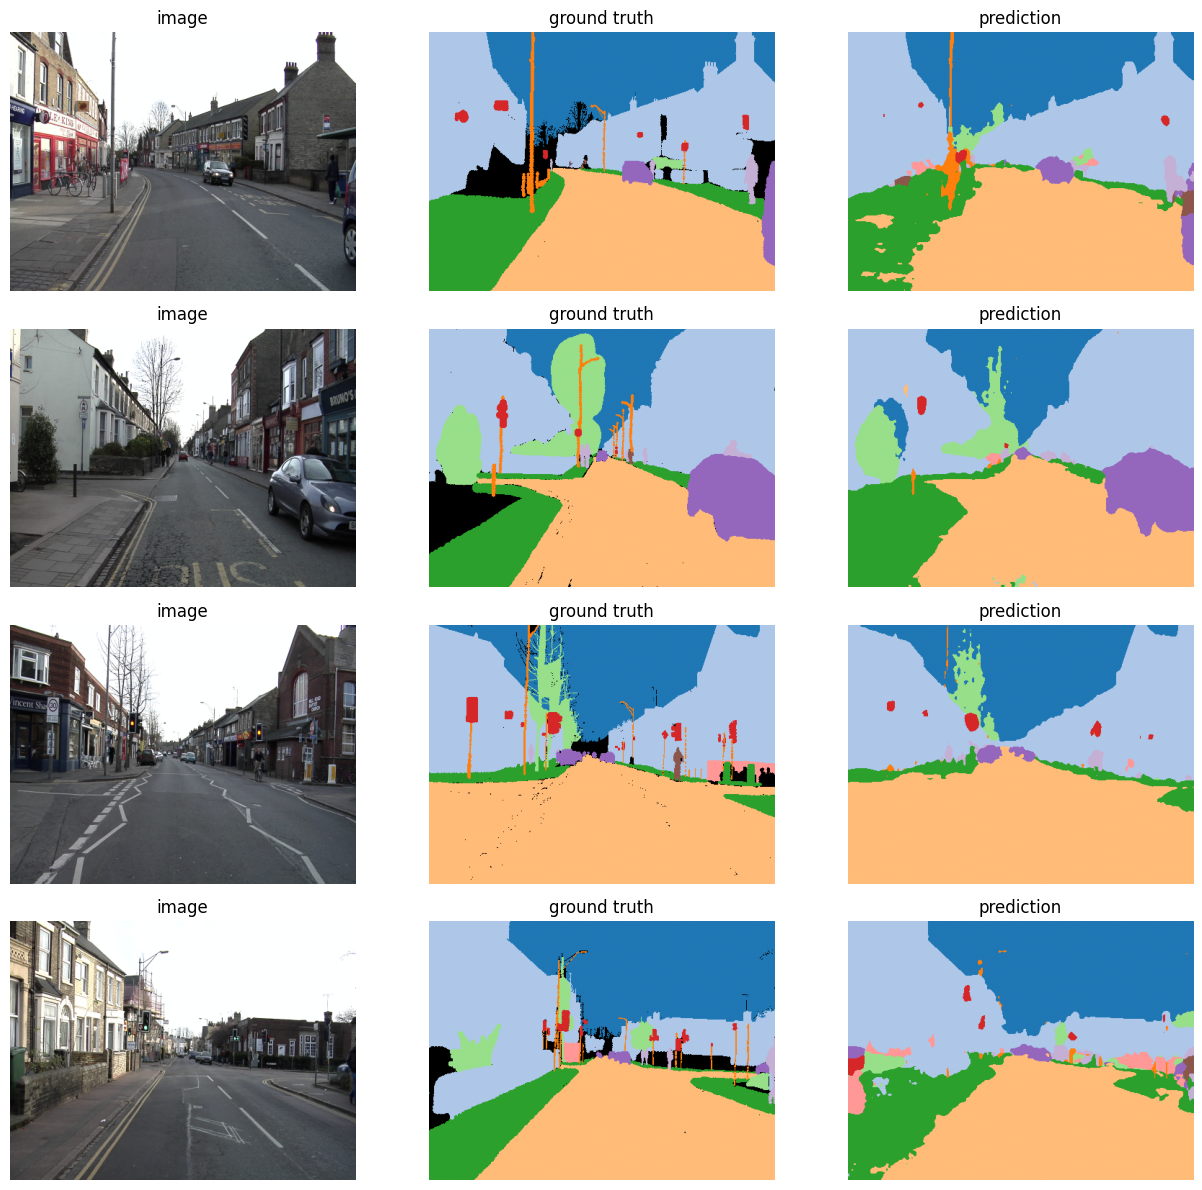

In [8]:
import matplotlib.pyplot as plt

palette = np.array([plt.cm.tab20(i)[:3] for i in range(NUM_CLASSES)] + [(0, 0, 0)])
model.eval()
fig, axes = plt.subplots(4, 3, figsize=(13, 12))
for r, i in enumerate(random.sample(range(len(test_ds)), 4)):
    x, y = test_ds[i]
    with torch.no_grad():
        pred = forward_logits(x[None].to(device), y.shape).argmax(1)[0].cpu().numpy()
    img = (x.permute(1, 2, 0).numpy() * STD + MEAN).clip(0, 1)
    for ax, im, title in zip(axes[r], [img, palette[y.numpy()], palette[pred]],
                             ["image", "ground truth", "prediction"]):
        ax.imshow(im); ax.set_title(title); ax.axis("off")
plt.tight_layout(); plt.show()